
### LogP Prediction — Full Benchmark
### Feature Sets: Descriptors | Fingerprints | Combined
### Models: Linear Regression | Decision Tree | Random Forest | XGBoost
### Evaluation: 5-Fold CV + 10-Fold CV + Hold-out Test Set
=========================================================================


## Phase 1: Setup & Data Loading

In [1]:
# --- 1. IMPORTS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# --- 1. DATA LOADING ---

path = r"C:\Users\Admin\Desktop\CS\ChemCompitiion\Lipophilicity.csv"

df = pd.read_csv(path)
print(df.head())

   CMPD_CHEMBLID   exp                                             smiles
0   CHEMBL596271  3.54            Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1  CHEMBL1951080 -1.18  COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2     CHEMBL1771  3.69             COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3   CHEMBL234951  3.37  OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4   CHEMBL565079  3.10  Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


## Phase 2: Exploratory Data Analysis (EDA)

### 2.1 Target Variable Analysis

In [3]:
df.shape

(4200, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CMPD_CHEMBLID  4200 non-null   object 
 1   exp            4200 non-null   float64
 2   smiles         4200 non-null   object 
dtypes: float64(1), object(2)
memory usage: 98.6+ KB


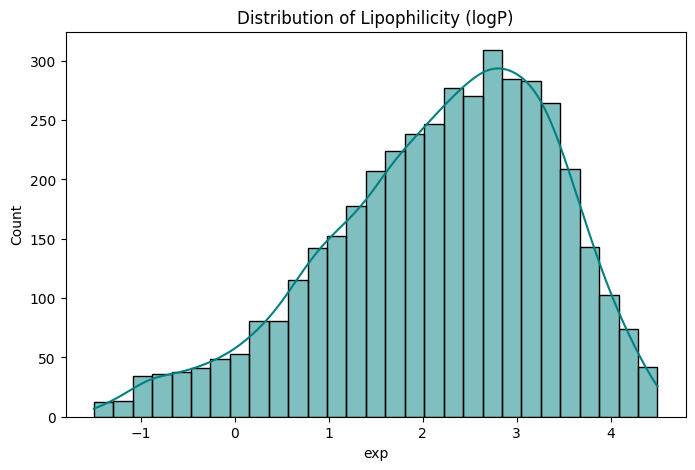

In [5]:
%matplotlib inline

plt.figure(figsize=(8, 5))
sns.histplot(df['exp'], kde=True, color='teal')
plt.title('Distribution of Lipophilicity (logP)')
plt.savefig('Distribution of Lipophilicity (logP)')
plt.show()

In [6]:
df.describe()

,exp
count,4200.000000
mean,2.186336
std,1.203004
min,-1.500000
25%,1.410000
50%,2.360000
75%,3.100000
max,4.500000


### 2.2 SMILES Validation

In [7]:
# --- 2.2.1. FEATURE GENERATION ---
from rdkit.Chem import Descriptors, AllChem
# 2.2.1.1 Molecular Descriptors (18 features)
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None
    return {
        'MW'         : Descriptors.MolWt(mol),
        'LogP_calc'  : Descriptors.MolLogP(mol),
        'TPSA'       : Descriptors.TPSA(mol),
        'HBD'        : Descriptors.NumHDonors(mol),
        'HBA'        : Descriptors.NumHAcceptors(mol),
        'RotBonds'   : Descriptors.NumRotatableBonds(mol),
        'AroRings'   : Descriptors.NumAromaticRings(mol),
        'RingCount'  : Descriptors.RingCount(mol),
        'fCSP3'      : Descriptors.FractionCSP3(mol),
        'LabuteASA'  : Descriptors.LabuteASA(mol),
        'BertzCT'    : Descriptors.BertzCT(mol),
        'Chi0v'      : Descriptors.Chi0v(mol),
        'Chi1v'      : Descriptors.Chi1v(mol),
        'Kappa1'     : Descriptors.Kappa1(mol),
        'Kappa2'     : Descriptors.Kappa2(mol),
        'PEOE_VSA1'  : Descriptors.PEOE_VSA1(mol),
        'SMR_VSA1'   : Descriptors.SMR_VSA1(mol),
        'SlogP_VSA1' : Descriptors.SlogP_VSA1(mol),
    }

# 2.2.1.2 Morgan Fingerprints (1024 bits, radius=2)
def get_fingerprint(smiles, radius=2, nbits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None
    generator = AllChem.GetMorganGenerator(radius=radius, fpSize=nbits)
    fp = generator.GetFingerprint(mol)
    return np.array(fp)

# 2.2.1.3 Apply to dataset
print("Generating descriptors and fingerprints...")

desc_list, fp_list, valid_indices = [], [], []

for idx, row in df.iterrows():
    desc = get_descriptors(row['smiles'])
    fp   = get_fingerprint(row['smiles'])
    if desc is not None and fp is not None:
        desc_list.append(desc)
        fp_list.append(fp)
        valid_indices.append(idx)

# Build clean dataframes
desc_df = pd.DataFrame(desc_list).reset_index(drop=True)
fp_df   = pd.DataFrame(fp_list,
                        columns=[f'fp_{i}' for i in range(1024)]
                       ).reset_index(drop=True)
y       = df.loc[valid_indices, 'exp'].reset_index(drop=True)

print(f"Valid molecules   : {len(valid_indices)}")
print(f"Descriptor shape  : {desc_df.shape}")
print(f"Fingerprint shape : {fp_df.shape}")
print(f"Target shape      : {y.shape}")
print(f"Duplicate columns : {desc_df.columns.duplicated().any()}")

Generating descriptors and fingerprints...
Valid molecules   : 4200
Descriptor shape  : (4200, 18)
Fingerprint shape : (4200, 1024)
Target shape      : (4200,)
Duplicate columns : False


In [8]:
# --- 2.2.2. BUILD THREE FEATURE SETS ---

# Remove HeavyAtoms — multicollinearity with MW (r=0.98)
desc_features = [c for c in desc_df.columns if c != 'HeavyAtoms']

X_desc     = desc_df[desc_features].copy()          # Descriptors only
X_fp       = fp_df.copy()                            # Fingerprints only
X_combined = pd.concat([X_desc, fp_df], axis=1)     # Combined

# Fill any NaNs
X_desc     = X_desc.fillna(X_desc.mean())
X_fp       = X_fp.fillna(0)
X_combined = X_combined.fillna(X_combined.mean())

print(f"Feature set shapes:")
print(f"  Descriptors only : {X_desc.shape}")
print(f"  Fingerprints only: {X_fp.shape}")
print(f"  Combined         : {X_combined.shape}")

Feature set shapes:
  Descriptors only : (4200, 18)
  Fingerprints only: (4200, 1024)
  Combined         : (4200, 1042)


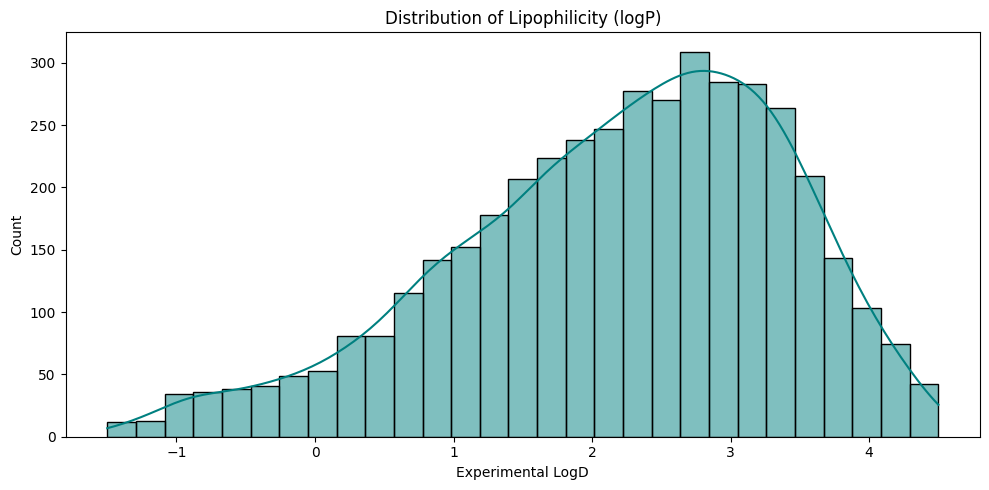

count    4200.000000
mean        2.186336
std         1.203004
min        -1.500000
25%         1.410000
50%         2.360000
75%         3.100000
max         4.500000
Name: exp, dtype: float64


In [9]:
# --- 2.2.3. EDA (on descriptor set — same as original project) ---

# 2.2.3.1 LogP distribution
plt.figure(figsize=(10, 5))
sns.histplot(y, kde=True, color='teal')
plt.title('Distribution of Lipophilicity (logP)')
plt.xlabel('Experimental LogD')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(y.describe())

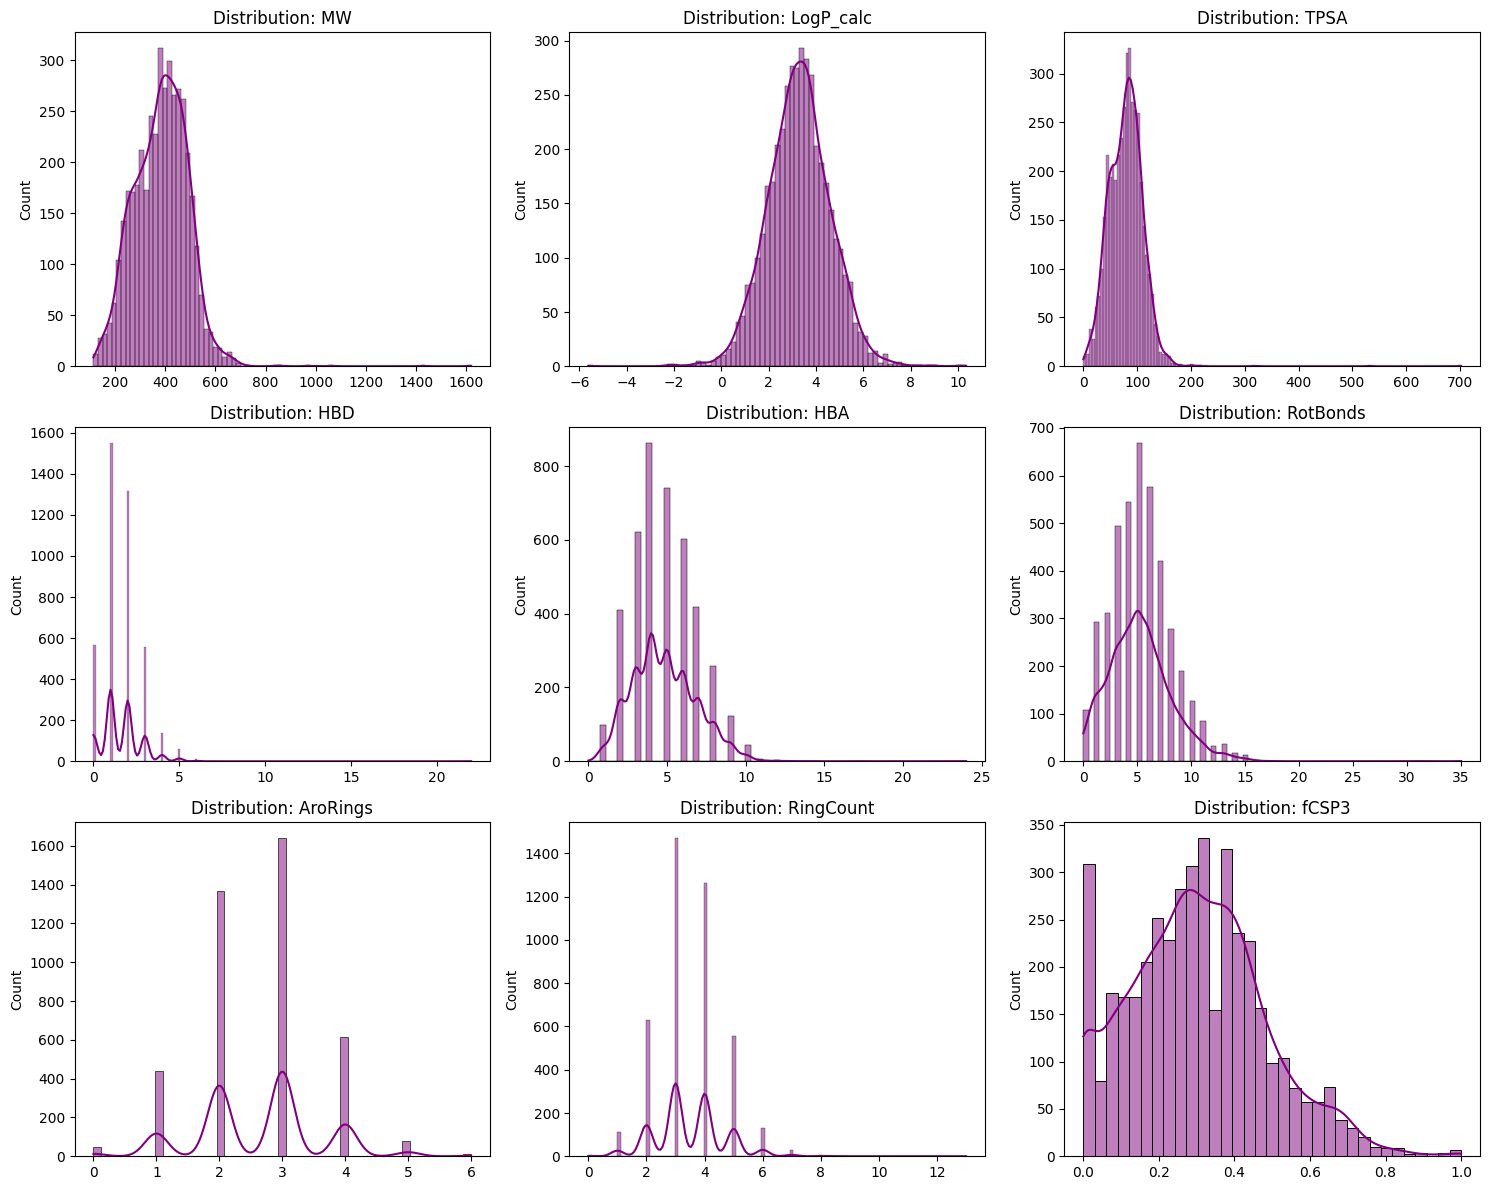

In [10]:
# 2.2.3.2 Descriptor distributions
eda_features = ['MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA',
                'RotBonds', 'AroRings', 'RingCount', 'fCSP3']

plt.figure(figsize=(15, 12))
for i, feat in enumerate(eda_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(desc_df[feat], kde=True, color='purple')
    plt.title(f'Distribution: {feat}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

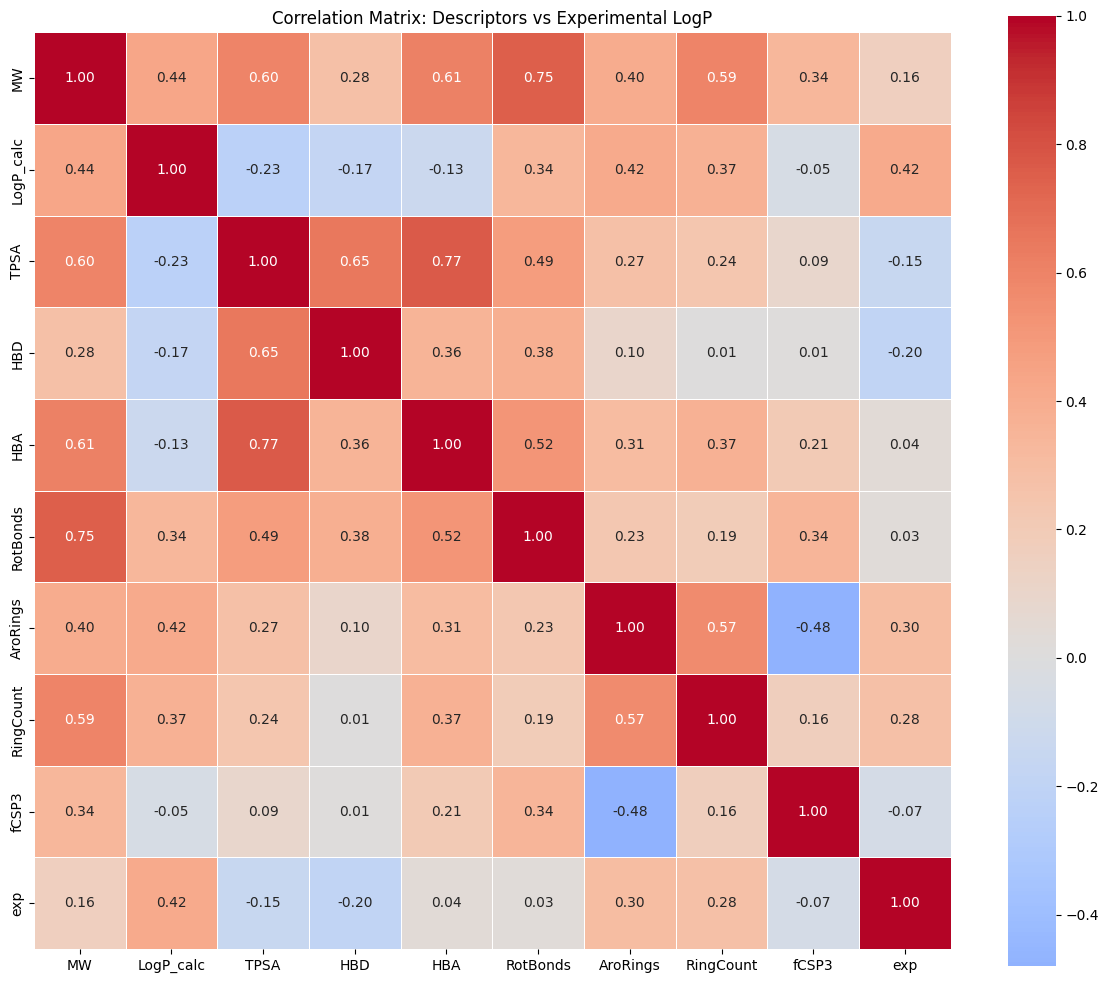

In [11]:
# 2.2.3.3 Correlation heatmap
corr_df = desc_df[eda_features].copy()
corr_df['exp'] = y.values

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Descriptors vs Experimental LogP')
plt.tight_layout()
plt.show()

In [12]:
# 2.2.3.4 Variance report
print("--- Variance Report ---")
variance = X_desc.var().sort_values()
print(variance)
low_var = variance[variance < 0.01].index.tolist()
print(f"\nNear-zero variance features: {low_var}")

--- Variance Report ---
fCSP3              0.032650
AroRings           0.946677
RingCount          1.305358
HBD                1.350683
LogP_calc          1.749793
HBA                4.174320
Kappa2             7.677769
Chi1v              8.121877
RotBonds           8.451740
Chi0v             19.858007
Kappa1            33.092460
SlogP_VSA1        42.528025
PEOE_VSA1         61.727776
SMR_VSA1          79.201243
TPSA            1028.810559
LabuteASA       1902.415311
MW             11450.162764
BertzCT       109216.796439
dtype: float64

Near-zero variance features: []


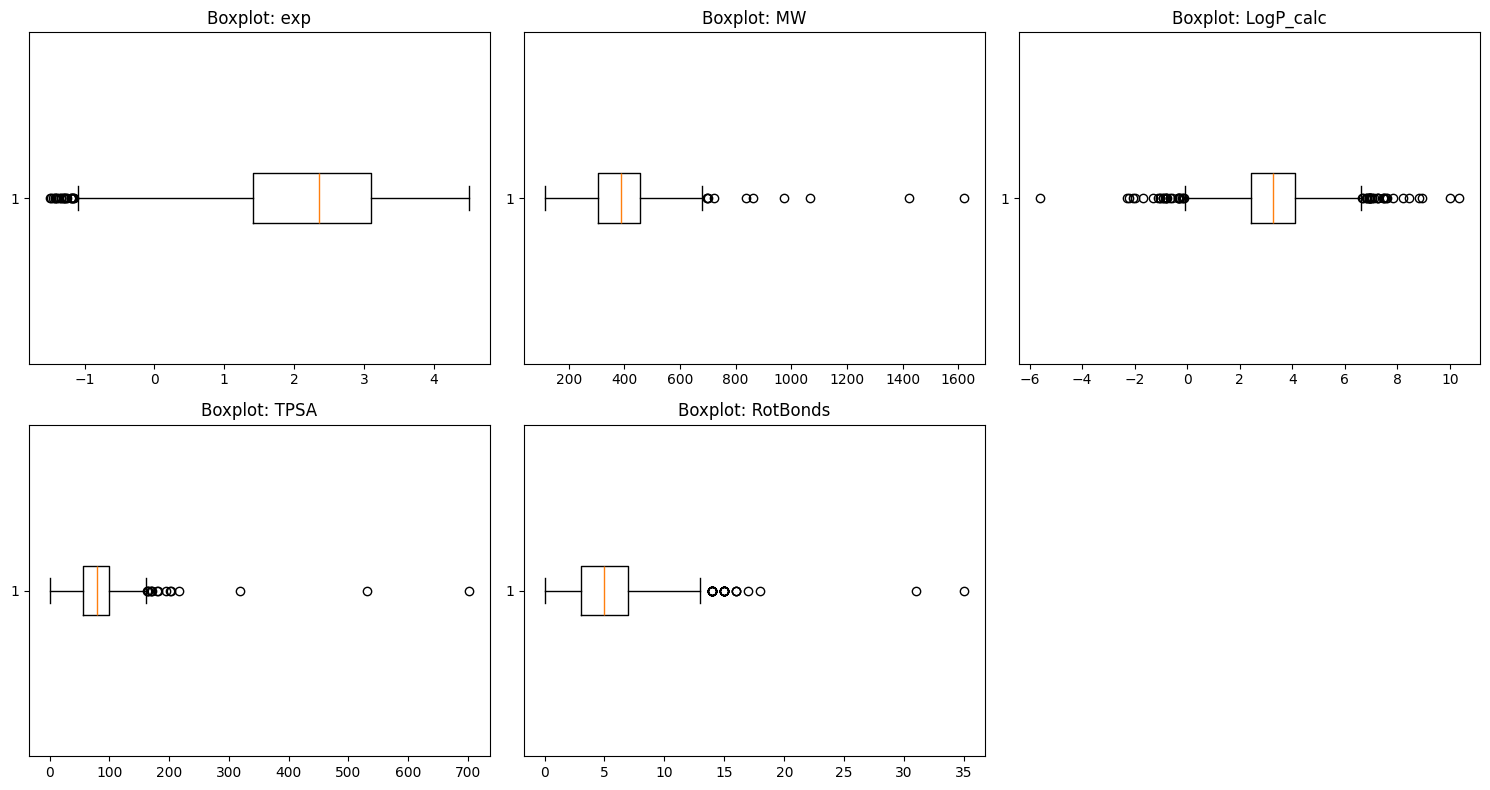

In [13]:
# 2.2.3.5 Outlier boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(['exp', 'MW', 'LogP_calc', 'TPSA', 'RotBonds']):
    data = y if feat == 'exp' else desc_df[feat]
    axes[i].boxplot(data, vert=False)
    axes[i].set_title(f'Boxplot: {feat}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# --- 3. TRAIN/TEST SPLIT ---
# Split indices — same split applied to all three feature sets
X_train_d, X_test_d, y_train, y_test = train_test_split(
    X_desc, y, test_size=0.2, random_state=42
)
X_train_fp, X_test_fp = (
    X_fp.iloc[X_train_d.index],
    X_fp.iloc[X_test_d.index]
)
X_train_c, X_test_c = (
    X_combined.iloc[X_train_d.index],
    X_combined.iloc[X_test_d.index]
)

# Reset indices
for df_ in [X_train_d, X_test_d, X_train_fp, X_test_fp,
            X_train_c, X_test_c]:
    df_.reset_index(drop=True, inplace=True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")

Train size: 3360 | Test size: 840


In [15]:
from xgboost import XGBRegressor

In [20]:
# --- 4. MODEL AND PIPELINE SETUP ---

def make_pipelines():
    return {
        'Linear Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  LinearRegression())
        ]),
        'Decision Tree': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  DecisionTreeRegressor(max_depth=5, random_state=42))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestRegressor(
                            n_estimators=100, random_state=42, n_jobs=-1))
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  XGBRegressor(
                            n_estimators=100, learning_rate=0.1,
                            max_depth=6, random_state=42,
                            verbosity=0, n_jobs=-1))
        ])
    }

feature_sets = {
    'Descriptors'  : (X_train_d,  X_test_d),
    'Fingerprints' : (X_train_fp, X_test_fp),
    'Combined'     : (X_train_c,  X_test_c),
}

print("Pipelines ready.")

Pipelines ready.


In [23]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [24]:
# --- 5. CROSS-VALIDATION ---
# 5-fold and 10-fold on training set

cv5  = KFold(n_splits=5,  shuffle=True, random_state=42)
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []

print("Running cross-validation... (this may take a few minutes)\n")

for fs_name, (X_train, X_test) in feature_sets.items():
    for model_name, pipeline in make_pipelines().items():

        # 5-fold
        scores_5 = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv5, scoring='r2', n_jobs=-1
        )
        rmse_5 = np.sqrt(-cross_val_score(
            pipeline, X_train, y_train,
            cv=cv5, scoring='neg_mean_squared_error', n_jobs=-1
        ))

        # 10-fold
        scores_10 = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv10, scoring='r2', n_jobs=-1
        )
        rmse_10 = np.sqrt(-cross_val_score(
            pipeline, X_train, y_train,
            cv=cv10, scoring='neg_mean_squared_error', n_jobs=-1
        ))

        cv_results.append({
            'Feature Set'    : fs_name,
            'Model'          : model_name,
            'CV5 R² Mean'    : scores_5.mean(),
            'CV5 R² Std'     : scores_5.std(),
            'CV5 RMSE Mean'  : rmse_5.mean(),
            'CV10 R² Mean'   : scores_10.mean(),
            'CV10 R² Std'    : scores_10.std(),
            'CV10 RMSE Mean' : rmse_10.mean(),
        })

        print(f"{fs_name} | {model_name}")
        print(f"  5-fold  R²: {scores_5.mean():.3f} ± {scores_5.std():.3f}")
        print(f"  10-fold R²: {scores_10.mean():.3f} ± {scores_10.std():.3f}\n")

cv_df = pd.DataFrame(cv_results)
print("\nCross-validation complete.")

Running cross-validation... (this may take a few minutes)

Descriptors | Linear Regression
  5-fold  R²: 0.275 ± 0.015
  10-fold R²: 0.268 ± 0.051

Descriptors | Decision Tree
  5-fold  R²: 0.264 ± 0.027
  10-fold R²: 0.269 ± 0.044

Descriptors | Random Forest
  5-fold  R²: 0.520 ± 0.026
  10-fold R²: 0.533 ± 0.038

Descriptors | XGBoost
  5-fold  R²: 0.513 ± 0.020
  10-fold R²: 0.523 ± 0.034

Fingerprints | Linear Regression
  5-fold  R²: 0.169 ± 0.070
  10-fold R²: 0.235 ± 0.063

Fingerprints | Decision Tree
  5-fold  R²: 0.114 ± 0.023
  10-fold R²: 0.110 ± 0.039

Fingerprints | Random Forest
  5-fold  R²: 0.460 ± 0.012
  10-fold R²: 0.470 ± 0.039

Fingerprints | XGBoost
  5-fold  R²: 0.458 ± 0.019
  10-fold R²: 0.463 ± 0.029

Combined | Linear Regression
  5-fold  R²: 0.323 ± 0.047
  10-fold R²: 0.388 ± 0.053

Combined | Decision Tree
  5-fold  R²: 0.364 ± 0.025
  10-fold R²: 0.360 ± 0.043

Combined | Random Forest
  5-fold  R²: 0.614 ± 0.013
  10-fold R²: 0.620 ± 0.032

Combined | 

In [25]:
# --- 6. FINAL EVALUATION ON HOLD-OUT TEST SET ---

test_results = []

for fs_name, (X_train, X_test) in feature_sets.items():
    for model_name, pipeline in make_pipelines().items():

        # Fit on full training set
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        test_results.append({
            'Feature Set' : fs_name,
            'Model'       : model_name,
            'R²'          : r2_score(y_test, y_pred),
            'MAE'         : mean_absolute_error(y_test, y_pred),
            'RMSE'        : np.sqrt(mean_squared_error(y_test, y_pred)),
            'y_pred'      : y_pred
        })

test_df = pd.DataFrame(test_results)

# Display results table
display_df = test_df[['Feature Set', 'Model', 'R²', 'MAE', 'RMSE']].copy()
display_df = display_df.sort_values('R²', ascending=False)
display_df[['R²', 'MAE', 'RMSE']] = display_df[
    ['R²', 'MAE', 'RMSE']].round(3)

print("\n=== FINAL TEST SET RESULTS ===")
print(display_df.to_string(index=False))


=== FINAL TEST SET RESULTS ===
 Feature Set             Model    R²   MAE  RMSE
    Combined           XGBoost 0.639 0.550 0.730
    Combined     Random Forest 0.638 0.540 0.732
 Descriptors     Random Forest 0.540 0.612 0.824
 Descriptors           XGBoost 0.533 0.624 0.830
Fingerprints     Random Forest 0.505 0.638 0.856
    Combined Linear Regression 0.496 0.651 0.863
Fingerprints           XGBoost 0.485 0.674 0.873
Fingerprints Linear Regression 0.341 0.743 0.987
    Combined     Decision Tree 0.333 0.777 0.992
 Descriptors     Decision Tree 0.287 0.810 1.026
 Descriptors Linear Regression 0.263 0.833 1.043
Fingerprints     Decision Tree 0.135 0.890 1.131


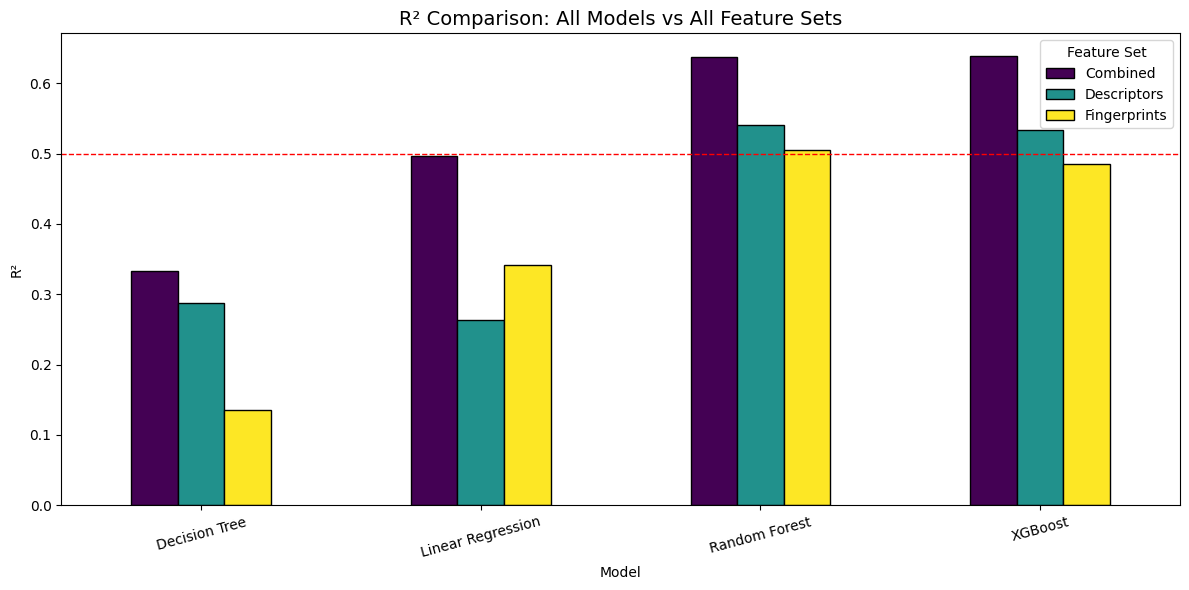

In [26]:
# --- 7. VISUALIZATION ---

# 7.1 R² comparison bar chart across feature sets and models
pivot = display_df.pivot(
    index='Model', columns='Feature Set', values='R²'
)

pivot.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('R² Comparison: All Models vs All Feature Sets', fontsize=14)
plt.ylabel('R²')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.legend(title='Feature Set')
plt.axhline(y=0.5, color='red', linestyle='--',
            linewidth=1, label='R²=0.5 threshold')
plt.tight_layout()
plt.show()

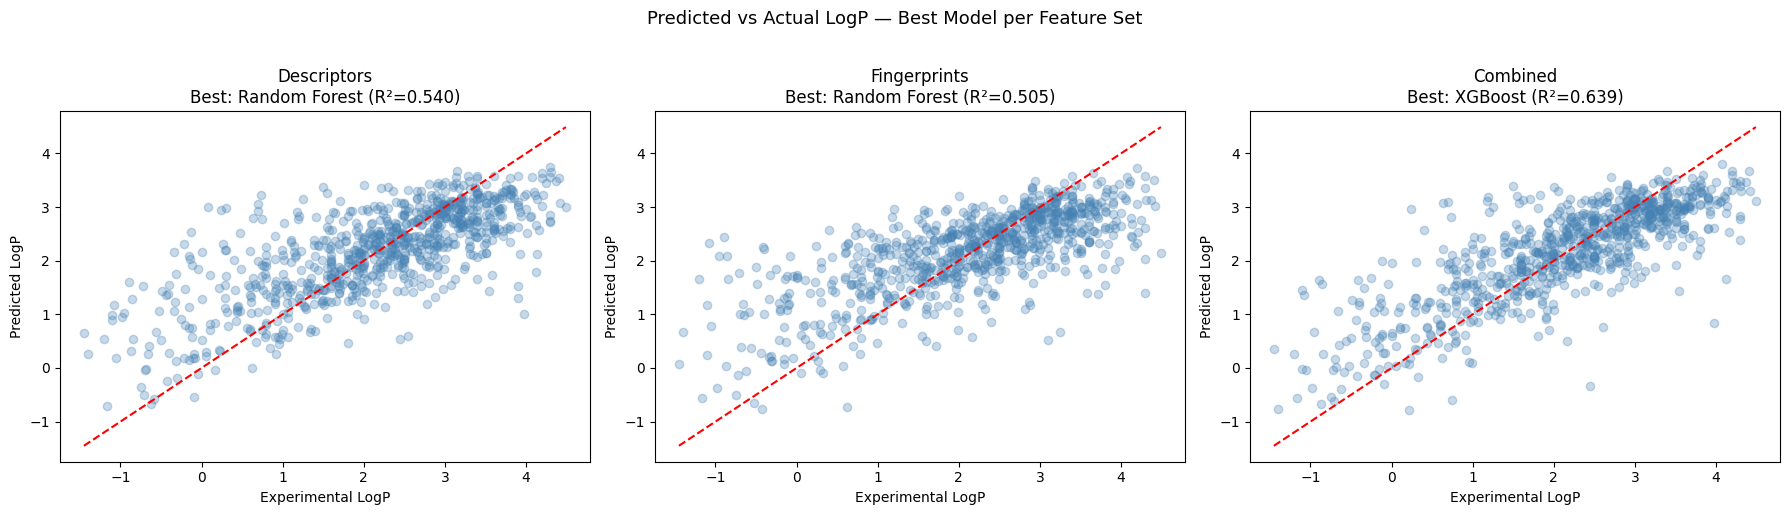

In [27]:
# 7.2 Predicted vs Actual — best model per feature set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, fs_name in zip(axes, ['Descriptors', 'Fingerprints', 'Combined']):
    # Find best model for this feature set
    subset = test_df[test_df['Feature Set'] == fs_name]
    best   = subset.loc[subset['R²'].idxmax()]

    y_pred = best['y_pred']
    r2     = best['R²']
    model  = best['Model']

    ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Experimental LogP')
    ax.set_ylabel('Predicted LogP')
    ax.set_title(f'{fs_name}\nBest: {model} (R²={r2:.3f})')

plt.suptitle('Predicted vs Actual LogP — Best Model per Feature Set',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

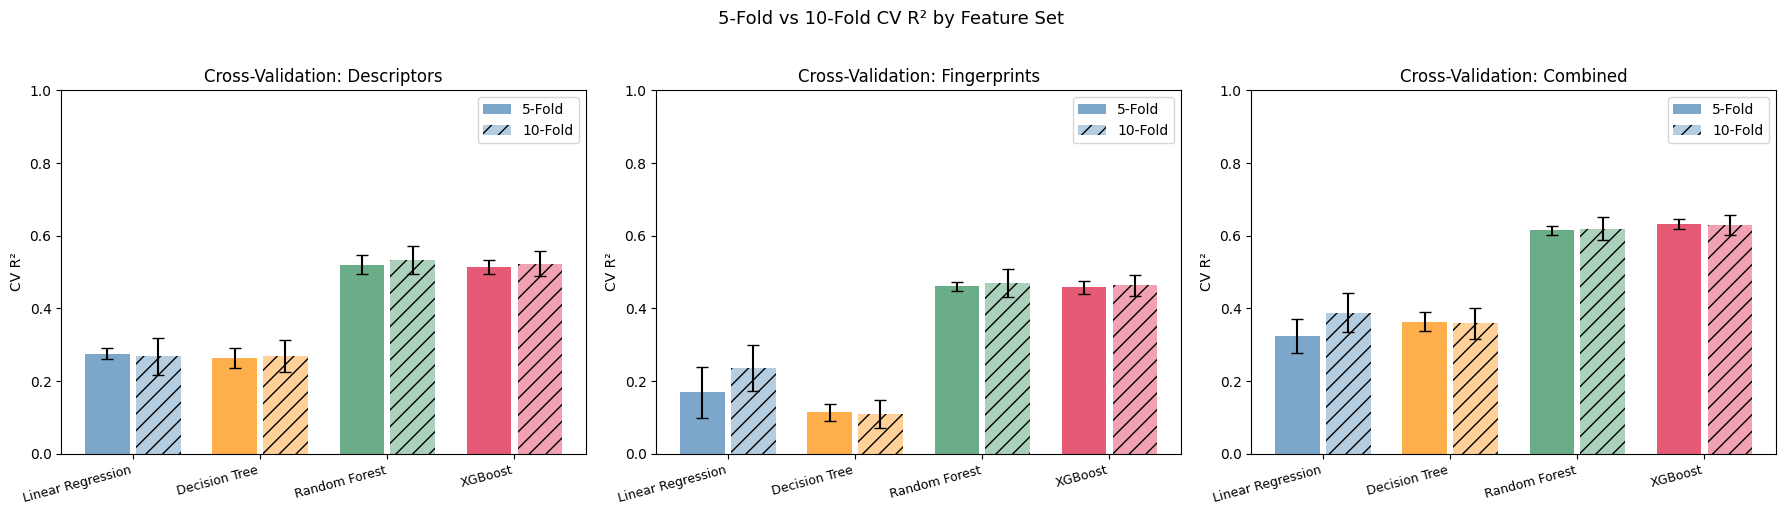

In [28]:
# 7.3 CV R² with error bars
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for ax, fs_name in zip(axes, ['Descriptors', 'Fingerprints', 'Combined']):
    subset = cv_df[cv_df['Feature Set'] == fs_name]
    x      = np.arange(len(models))

    ax.bar(x - 0.2, subset['CV5 R² Mean'],  0.35,
           yerr=subset['CV5 R² Std'],  label='5-Fold',
           color=colors, alpha=0.7, capsize=4)
    ax.bar(x + 0.2, subset['CV10 R² Mean'], 0.35,
           yerr=subset['CV10 R² Std'], label='10-Fold',
           color=colors, alpha=0.4, capsize=4, hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('CV R²')
    ax.set_title(f'Cross-Validation: {fs_name}')
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle('5-Fold vs 10-Fold CV R² by Feature Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

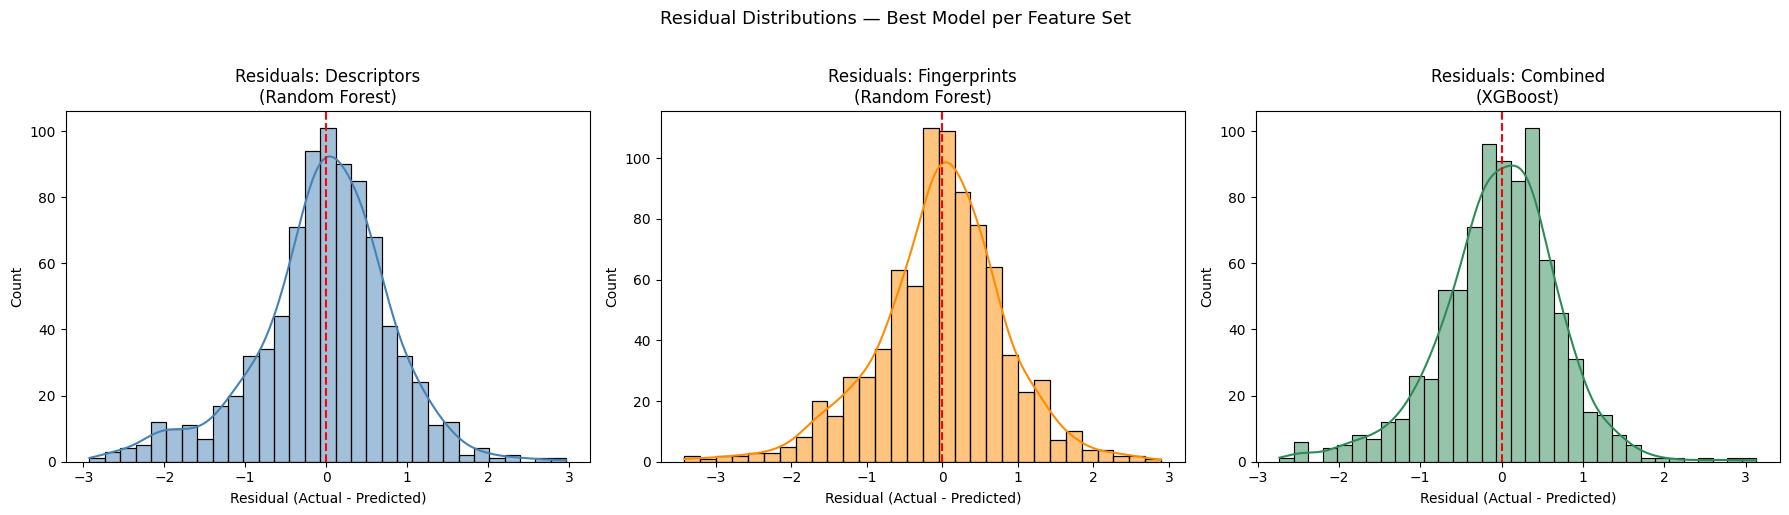

In [29]:
# 7.4 Residual distributions — best model per feature set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette   = ['steelblue', 'darkorange', 'seagreen']

for ax, (fs_name, color) in zip(
        axes, zip(['Descriptors', 'Fingerprints', 'Combined'], palette)):

    subset = test_df[test_df['Feature Set'] == fs_name]
    best   = subset.loc[subset['R²'].idxmax()]
    resid  = y_test - best['y_pred']

    sns.histplot(resid, kde=True, color=color, ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_title(f"Residuals: {fs_name}\n({best['Model']})")

plt.suptitle('Residual Distributions — Best Model per Feature Set',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

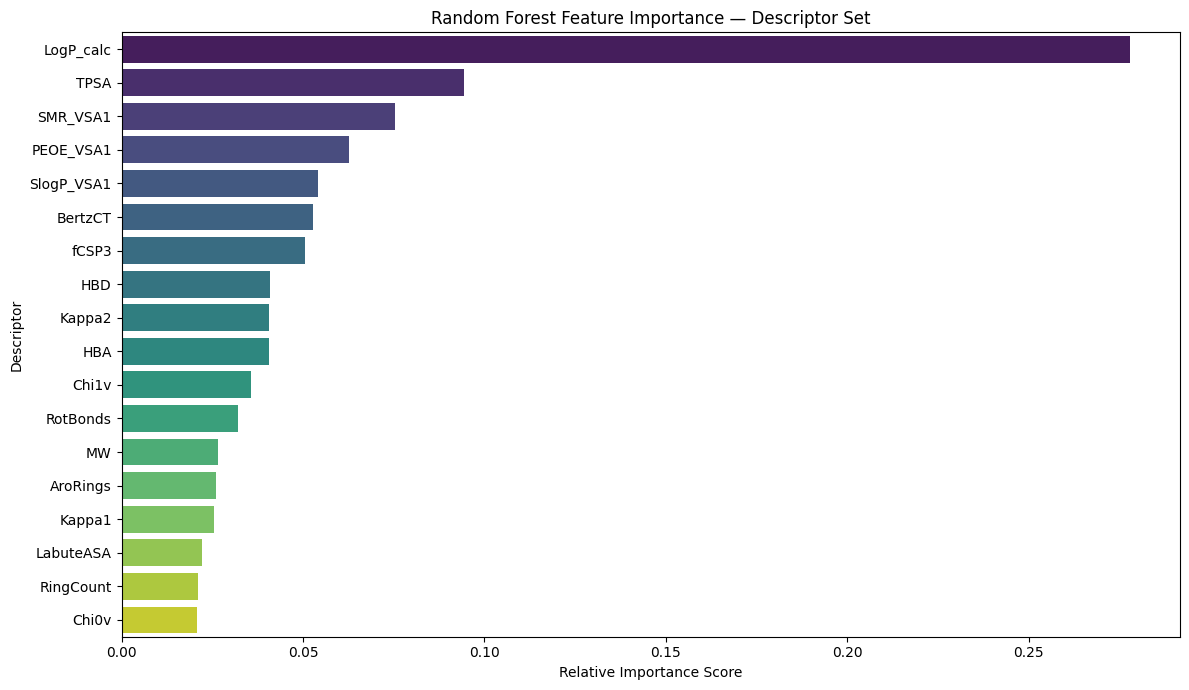

In [30]:
# 7.5 Random Forest feature importance — descriptor set only
# (fingerprints have 1024 features — not practical to visualize all)

desc_pipeline = make_pipelines()['Random Forest']
desc_pipeline.fit(X_train_d, y_train)

rf_model     = desc_pipeline.named_steps['model']
importances  = rf_model.feature_importances_
feat_names   = desc_features
indices      = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 7))
sns.barplot(
    x=importances[indices],
    y=[feat_names[i] for i in indices],
    palette='viridis'
)
plt.title('Random Forest Feature Importance — Descriptor Set')
plt.xlabel('Relative Importance Score')
plt.ylabel('Descriptor')
plt.tight_layout()
plt.show()

In [31]:
# --- 8. SUMMARY TABLE ---
print("\n" + "="*65)
print("COMPLETE BENCHMARK SUMMARY")
print("="*65)

for fs in ['Descriptors', 'Fingerprints', 'Combined']:
    print(f"\n--- {fs} ---")
    subset = display_df[display_df['Feature Set'] == fs][
        ['Model', 'R²', 'MAE', 'RMSE']
    ]
    print(subset.to_string(index=False))

print("\n--- Cross-Validation Summary (10-Fold R²) ---")
cv_summary = cv_df[['Feature Set', 'Model',
                     'CV10 R² Mean', 'CV10 R² Std']].copy()
cv_summary[['CV10 R² Mean', 'CV10 R² Std']] = cv_summary[
    ['CV10 R² Mean', 'CV10 R² Std']].round(3)
cv_summary = cv_summary.sort_values('CV10 R² Mean', ascending=False)
print(cv_summary.to_string(index=False))


COMPLETE BENCHMARK SUMMARY

--- Descriptors ---
            Model    R²   MAE  RMSE
    Random Forest 0.540 0.612 0.824
          XGBoost 0.533 0.624 0.830
    Decision Tree 0.287 0.810 1.026
Linear Regression 0.263 0.833 1.043

--- Fingerprints ---
            Model    R²   MAE  RMSE
    Random Forest 0.505 0.638 0.856
          XGBoost 0.485 0.674 0.873
Linear Regression 0.341 0.743 0.987
    Decision Tree 0.135 0.890 1.131

--- Combined ---
            Model    R²   MAE  RMSE
          XGBoost 0.639 0.550 0.730
    Random Forest 0.638 0.540 0.732
Linear Regression 0.496 0.651 0.863
    Decision Tree 0.333 0.777 0.992

--- Cross-Validation Summary (10-Fold R²) ---
 Feature Set             Model  CV10 R² Mean  CV10 R² Std
    Combined           XGBoost         0.630        0.029
    Combined     Random Forest         0.620        0.032
 Descriptors     Random Forest         0.533        0.038
 Descriptors           XGBoost         0.523        0.034
Fingerprints     Random Forest    

In [32]:
# --- 9. PREDICTION FUNCTION ---
# Uses best overall model (Combined + XGBoost most likely)

# Train best pipeline — Combined features, XGBoost
best_pipeline = make_pipelines()['XGBoost']
best_pipeline.fit(X_train_c, y_train)

def predict_logp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES string."

    desc = get_descriptors(smiles)
    fp   = get_fingerprint(smiles)

    if desc is None or fp is None:
        return "Could not generate features."

    desc_series = pd.Series(desc)[desc_features]
    fp_series   = pd.Series(fp, index=[f'fp_{i}' for i in range(1024)])
    combined    = pd.concat([desc_series, fp_series]).values.reshape(1, -1)
    combined_df = pd.DataFrame(
        combined,
        columns=list(desc_features) + [f'fp_{i}' for i in range(1024)]
    )

    prediction = best_pipeline.predict(combined_df)[0]
    return round(prediction, 3)


# Test predictions on known molecules
test_molecules = {
    'Caffeine'   : 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Aspirin'    : 'CC(=O)Oc1ccccc1C(=O)O',
    'Ibuprofen'  : 'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
}

print("\n--- Predictions on Known Molecules ---")
for name, smi in test_molecules.items():
    pred = predict_logp(smi)
    print(f"{name:15s}: Predicted LogP = {pred}")


--- Predictions on Known Molecules ---
Caffeine       : Predicted LogP = -0.20399999618530273
Aspirin        : Predicted LogP = -0.24899999797344208
Ibuprofen      : Predicted LogP = 0.753000020980835
Paracetamol    : Predicted LogP = 0.7860000133514404


In [ ]:
# --- 10. INTERACTIVE PREDICTOR ---
print("\n--- Molecular Lipophilicity Predictor (XGBoost + Combined Features) ---")
user_input = input("Enter a SMILES string: ")
result = predict_logp(user_input)

if isinstance(result, str) and "Invalid" in result:
    print(f"Error: {result}")
else:
    print(f"\nSMILES        : {user_input}")
    print(f"Predicted LogP: {result}")
    if result > 3:
        print("Insight: Highly lipophilic — may have solubility issues.")
    elif result < 1:
        print("Insight: Highly hydrophilic — may have membrane permeability issues.")
    else:
        print("Insight: Balanced drug-like lipophilicity.")


--- Molecular Lipophilicity Predictor (XGBoost + Combined Features) ---
